# Notebook 01 — Exploratory Data Analysis
**Dataset:** PaySim Synthetic Financial Transaction Dataset  
**Goal:** Hiểu phân phối dữ liệu, class imbalance, và các pattern AML có thể phát hiện được.

---
**Checklist:**
- [ ] Dataset overview (shape, dtypes, nulls)
- [ ] Class distribution & imbalance analysis
- [ ] Transaction type distribution
- [ ] Amount distribution (log scale)
- [ ] Temporal patterns (fraud by step/hour)
- [ ] Balance anomaly analysis
- [ ] AML pattern detection hints
- [ ] Correlation heatmap

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_PATH = '../paysim dataset.csv'

## 1. Load & Overview

In [4]:
# Load full dataset — ~6.3M rows, ~500MB
# Dùng dtype tối ưu để tiết kiệm RAM
dtype_map = {
    'step': 'int16',
    'type': 'category',
    'amount': 'float32',
    'nameOrig': 'str',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'str',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8',
}

df = pd.read_csv(DATA_PATH, dtype=dtype_map)
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape: (6362620, 11)
Memory: 1017.8 MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0


In [5]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
df.describe()

=== Data Types ===
step                 int16
type              category
amount             float32
nameOrig            object
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest            object
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
dtype: object

=== Missing Values ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== Basic Stats ===


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338834e+05,8.551137e+05,1.100702e+06,1.224997e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888242e+06,2.924048e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## 2. Class Distribution — Imbalance Analysis

Legitimate: 6,354,407 (99.871%)
Fraudulent: 8,213 (0.129%)
Imbalance ratio: 1:773


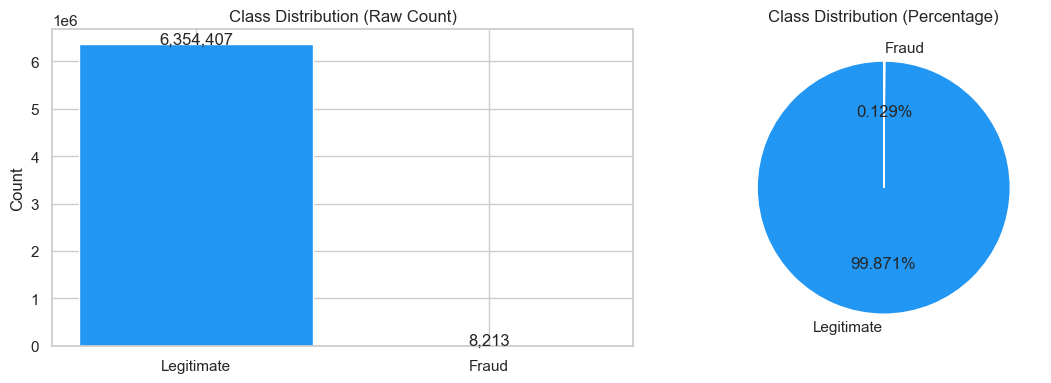

In [6]:
fraud_counts = df['isFraud'].value_counts()
fraud_ratio = fraud_counts[1] / len(df) * 100

print(f'Legitimate: {fraud_counts[0]:,} ({100 - fraud_ratio:.3f}%)')
print(f'Fraudulent: {fraud_counts[1]:,} ({fraud_ratio:.3f}%)')
print(f'Imbalance ratio: 1:{fraud_counts[0]//fraud_counts[1]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['#2196F3', '#F44336'])
axes[0].set_title('Class Distribution (Raw Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center')

axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2196F3', '#F44336'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

## 3. Transaction Type Analysis

          fraud_count  total_count  fraud_rate  fraud_rate_pct
type                                                          
TRANSFER         4097       532909    0.007688        0.768799
CASH_OUT         4116      2237500    0.001840        0.183955
CASH_IN             0      1399284    0.000000        0.000000
DEBIT               0        41432    0.000000        0.000000
PAYMENT             0      2151495    0.000000        0.000000


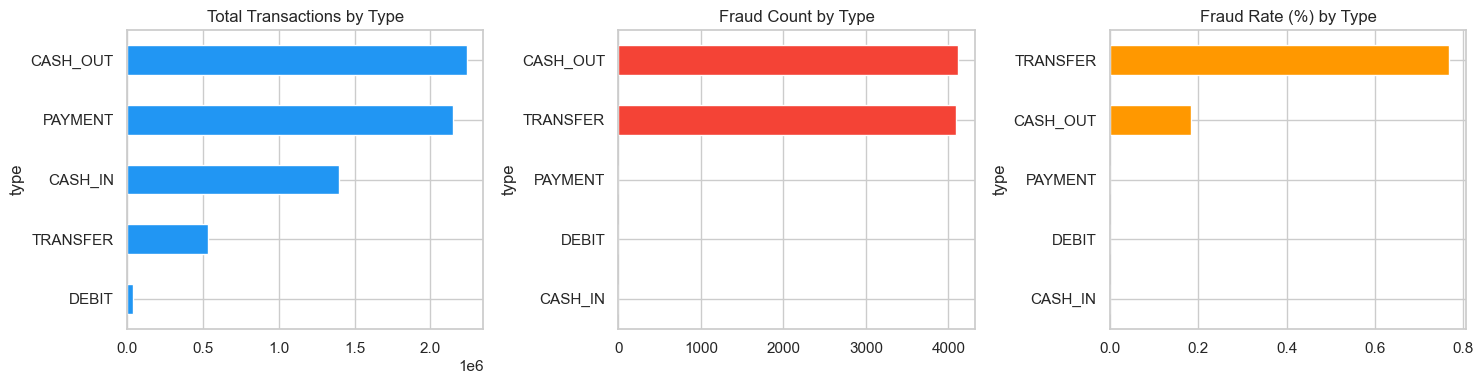

In [7]:
type_fraud = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
type_fraud.columns = ['fraud_count', 'total_count', 'fraud_rate']
type_fraud['fraud_rate_pct'] = type_fraud['fraud_rate'] * 100
print(type_fraud.sort_values('fraud_rate', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

type_fraud['total_count'].sort_values().plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Total Transactions by Type')

type_fraud['fraud_count'].sort_values().plot(kind='barh', ax=axes[1], color='#F44336')
axes[1].set_title('Fraud Count by Type')

type_fraud['fraud_rate_pct'].sort_values().plot(kind='barh', ax=axes[2], color='#FF9800')
axes[2].set_title('Fraud Rate (%) by Type')

plt.tight_layout()
plt.show()

# Key insight: Fraud only in TRANSFER and CASH_OUT

## 4. Amount Distribution

Amount statistics by class:
             count          mean        std   min            25%  \
isFraud                                                            
0        6354407.0  1.781970e+05   596237.0  0.01   13368.395020   
1           8213.0  1.467967e+06  2404253.0  0.00  127091.328125   

                  50%           75%         max  
isFraud                                          
0         74684.71875  2.083648e+05  92445520.0  
1        441423.43750  1.517772e+06  10000000.0  


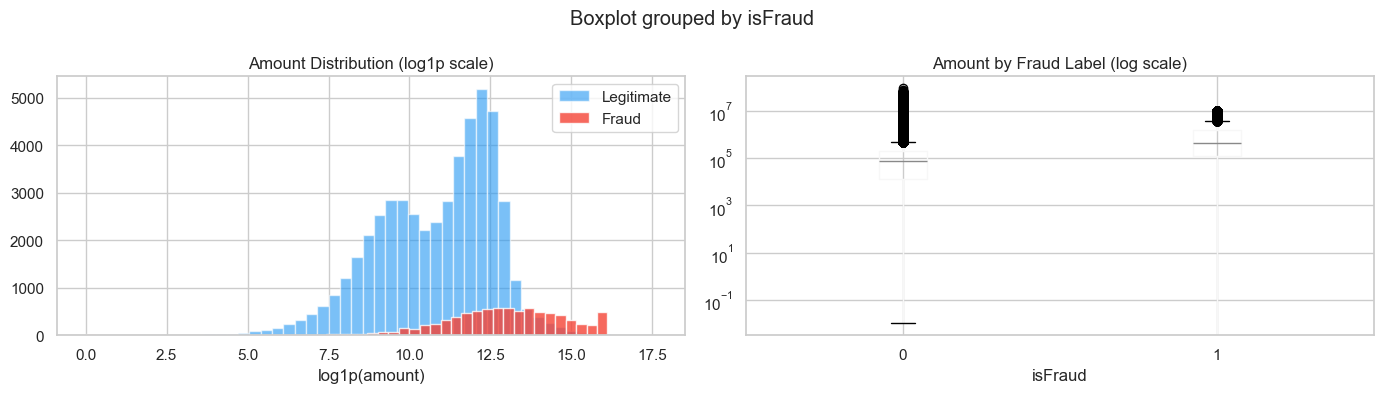

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Log-scale amount distribution
axes[0].hist(np.log1p(df[df['isFraud']==0]['amount'].sample(50000)), bins=50,
             alpha=0.6, color='#2196F3', label='Legitimate')
axes[0].hist(np.log1p(df[df['isFraud']==1]['amount']), bins=50,
             alpha=0.8, color='#F44336', label='Fraud')
axes[0].set_title('Amount Distribution (log1p scale)')
axes[0].set_xlabel('log1p(amount)')
axes[0].legend()

# Amount stats by class
amount_stats = df.groupby('isFraud')['amount'].describe()
print('Amount statistics by class:')
print(amount_stats)

# Boxplot
df.boxplot(column='amount', by='isFraud', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Amount by Fraud Label (log scale)')
axes[1].set_xlabel('isFraud')

plt.tight_layout()
plt.show()

## 5. Temporal Patterns

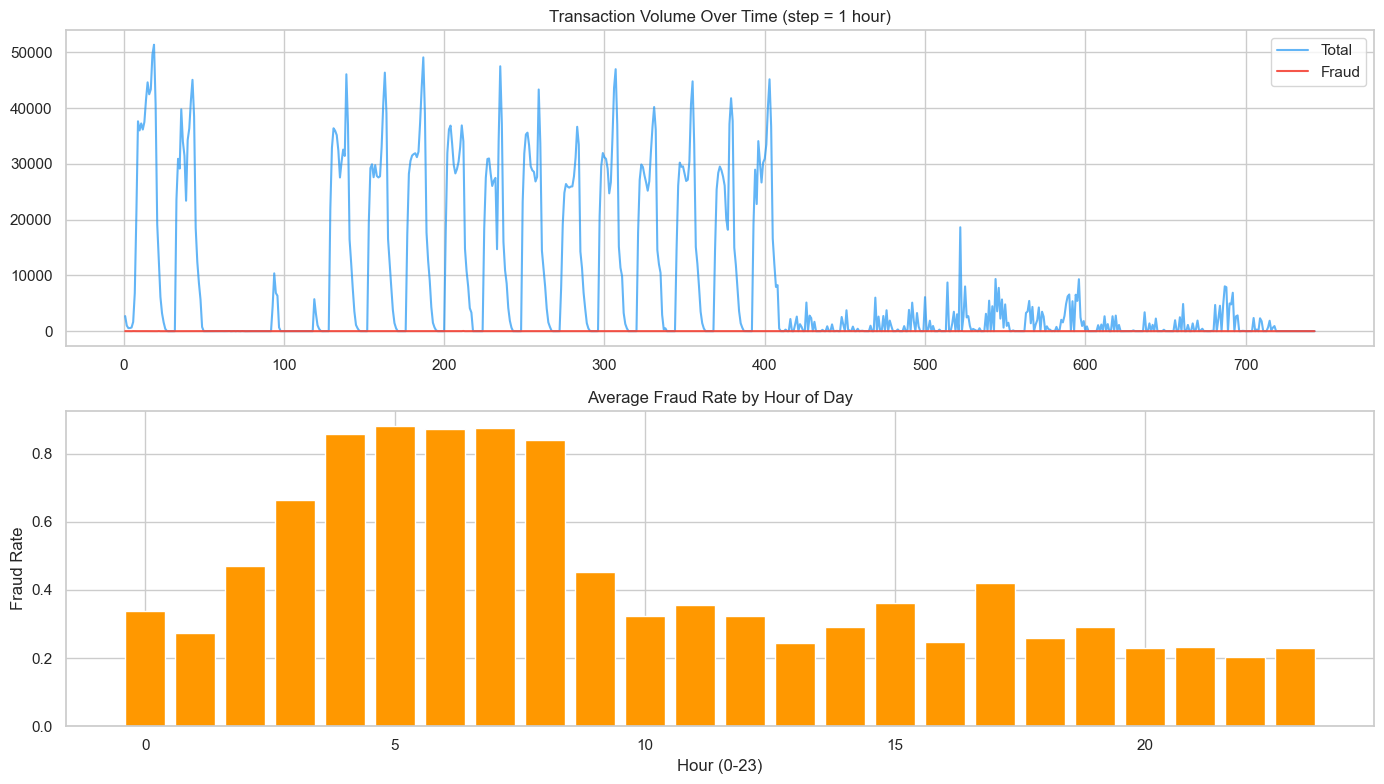

In [9]:
# step = 1 hour. 743 steps = ~31 days
temporal = df.groupby('step').agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum')
)
temporal['fraud_rate'] = temporal['fraud'] / temporal['total']
temporal['hour_of_day'] = temporal.index % 24
temporal['day'] = temporal.index // 24

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(temporal.index, temporal['total'], alpha=0.7, color='#2196F3', label='Total')
axes[0].plot(temporal.index, temporal['fraud'], alpha=0.9, color='#F44336', label='Fraud')
axes[0].set_title('Transaction Volume Over Time (step = 1 hour)')
axes[0].legend()

hourly_fraud_rate = temporal.groupby('hour_of_day')['fraud_rate'].mean()
axes[1].bar(hourly_fraud_rate.index, hourly_fraud_rate.values, color='#FF9800')
axes[1].set_title('Average Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

## 6. Balance Anomaly — AML Signal

=== Balance Drain Analysis ===
isFraud               0         1
balance_drain                    
0              0.999942  0.000058
1              0.997769  0.002231

=== Balance Discrepancy (balance_diff != 0 indicates anomaly) ===
Orig discrepancy != 0: 5,168,151 rows
Dest discrepancy != 0: 4,341,115 rows


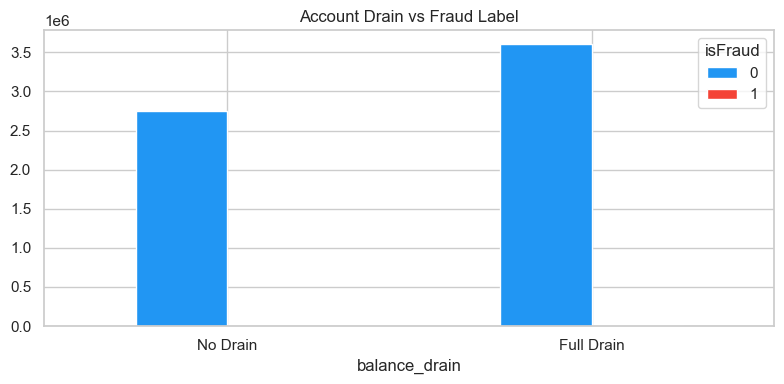

In [10]:
# AML pattern: sender's new balance = 0 after transaction (account drain)
df['balance_drain'] = (df['newbalanceOrig'] == 0).astype(int)
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['balance_diff_dest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

print('=== Balance Drain Analysis ===')
print(pd.crosstab(df['balance_drain'], df['isFraud'], normalize='index'))

print('\n=== Balance Discrepancy (balance_diff != 0 indicates anomaly) ===')
print(f"Orig discrepancy != 0: {(df['balance_diff_orig'].abs() > 0.01).sum():,} rows")
print(f"Dest discrepancy != 0: {(df['balance_diff_dest'].abs() > 0.01).sum():,} rows")

# Zero balance drain correlation with fraud
fig, ax = plt.subplots(figsize=(8, 4))
drain_fraud = df.groupby(['balance_drain', 'isFraud']).size().unstack(fill_value=0)
drain_fraud.plot(kind='bar', ax=ax, color=['#2196F3', '#F44336'])
ax.set_title('Account Drain vs Fraud Label')
ax.set_xticklabels(['No Drain', 'Full Drain'], rotation=0)
plt.tight_layout()
plt.show()

## 7. AML Pattern: Structuring Detection Hints

Transactions near threshold (90-100% of 200,000): 201,321
Fraud rate in near-threshold zone: 0.0006
Baseline fraud rate: 0.0013


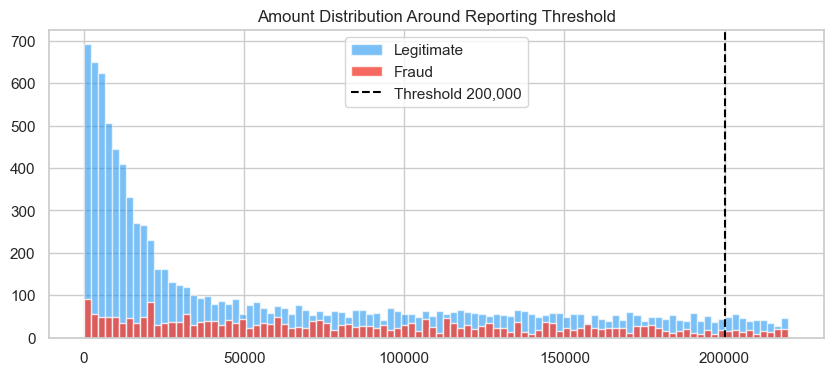

In [11]:
# Structuring: transactions clustered just below round thresholds
# PaySim doesn't have VND, but we simulate threshold at 200,000 (native units)
THRESHOLD = 200_000

near_threshold = df[(df['amount'] >= THRESHOLD * 0.9) & (df['amount'] < THRESHOLD)]
print(f'Transactions near threshold (90-100% of {THRESHOLD:,}): {len(near_threshold):,}')
print(f'Fraud rate in near-threshold zone: {near_threshold["isFraud"].mean():.4f}')
print(f'Baseline fraud rate: {df["isFraud"].mean():.4f}')

# Distribution around threshold
fig, ax = plt.subplots(figsize=(10, 4))
subset = df[df['amount'] <= THRESHOLD * 1.1]
ax.hist(subset[subset['isFraud']==0]['amount'].sample(min(10000, len(subset))), 
        bins=100, alpha=0.6, color='#2196F3', label='Legitimate')
ax.hist(subset[subset['isFraud']==1]['amount'], 
        bins=100, alpha=0.8, color='#F44336', label='Fraud')
ax.axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold {THRESHOLD:,}')
ax.set_title('Amount Distribution Around Reporting Threshold')
ax.legend()
plt.show()

## 8. Correlation Heatmap

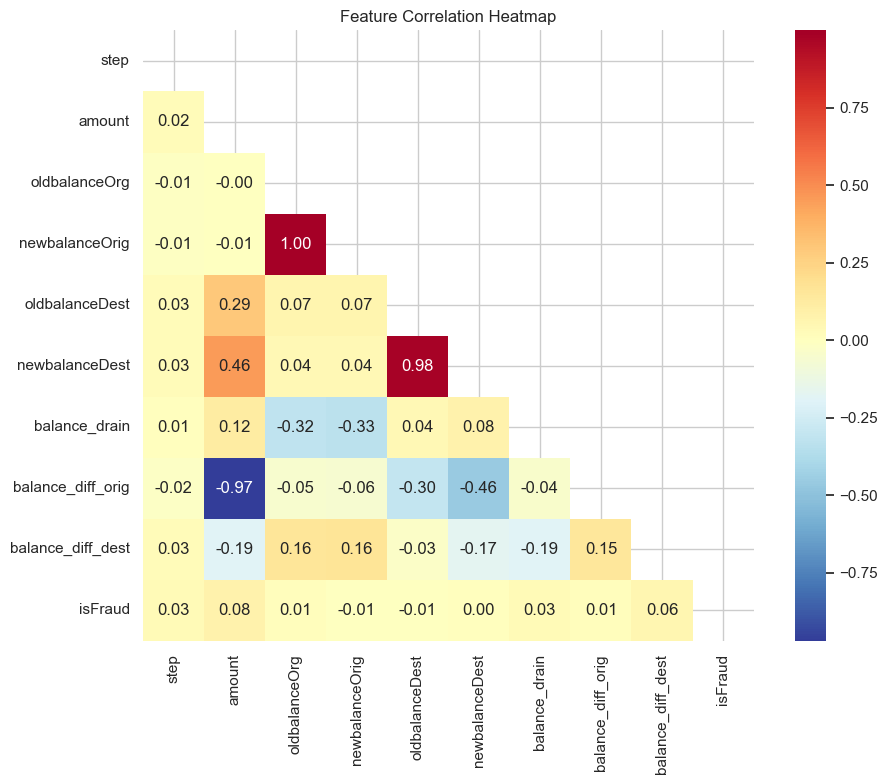


=== Correlation with isFraud (sorted) ===
amount               0.076688
balance_diff_dest    0.055120
step                 0.031578
balance_drain        0.029984
balance_diff_orig    0.011283
oldbalanceOrg        0.010154
newbalanceOrig      -0.008148
oldbalanceDest      -0.005885
newbalanceDest       0.000535
Name: isFraud, dtype: float64


In [12]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'balance_drain',
                'balance_diff_orig', 'balance_diff_dest', 'isFraud']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print('\n=== Correlation with isFraud (sorted) ===')
print(corr['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False))

## 9. Summary & Key Insights

In [13]:
print('='*60)
print('KEY INSIGHTS FOR AML MODEL')
print('='*60)
print(f"""
1. CLASS IMBALANCE: ~{fraud_ratio:.2f}% fraud → cần class_weight/scale_pos_weight
2. FRAUD TYPES: Chỉ TRANSFER và CASH_OUT có fraud → filter type trước
3. BALANCE DRAIN: newbalanceOrig=0 là signal mạnh
4. BALANCE DISCREPANCY: balance_diff != 0 → account manipulation
5. AMOUNT: Fraud thường có amount cao hơn median
6. TEMPORAL: Cần aggregate features theo window (1h, 24h, 7d)

NEXT STEPS → Notebook 02: Feature Engineering
  - Velocity features (tx count/amount per user per window)
  - Balance ratio features
  - Account age proxy
  - Network features (degree, fan-in/fan-out)
""")

KEY INSIGHTS FOR AML MODEL

1. CLASS IMBALANCE: ~0.13% fraud → cần class_weight/scale_pos_weight
2. FRAUD TYPES: Chỉ TRANSFER và CASH_OUT có fraud → filter type trước
3. BALANCE DRAIN: newbalanceOrig=0 là signal mạnh
4. BALANCE DISCREPANCY: balance_diff != 0 → account manipulation
5. AMOUNT: Fraud thường có amount cao hơn median
6. TEMPORAL: Cần aggregate features theo window (1h, 24h, 7d)

NEXT STEPS → Notebook 02: Feature Engineering
  - Velocity features (tx count/amount per user per window)
  - Balance ratio features
  - Account age proxy
  - Network features (degree, fan-in/fan-out)

